# Land Acquisition Delay Prediction & Risk Assessment — Enhanced Experiment

This notebook documents the improved machine learning pipeline supporting the **Predictive Analytics System for Early Detection of Land Acquisition Delays** (SIH project).

### Architecture & Pipeline Highlights:
- **Architecture**: Dual-Engine XGBoost (3-Class Risk Classifier + Calibrated Probability Regressor).
- **Key Features**: Domain risk interactions (Dispute Score, Severe Legal Risk, Possession Lag, Area per Owner, Unfunded Amount).
- **Risk Classification Accuracy**: **~93.00%** (Low: 96% F1, Medium: 90% F1, High: 91% F1).
- **Probability Estimation**: $R^2 = 0.9815$, Mean Absolute Error $= 2.17\%$.
- **Deployment**: Production FastAPI microservice (`main.py`) exposing `/predict` and `/predict/batch`.

## 1. Setup & Data Ingestion

In [1]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay, 
    accuracy_score, 
    classification_report, 
    mean_absolute_error, 
    r2_score, 
    roc_auc_score
)
from sklearn.model_selection import train_test_split

# Resolve paths relative to repo root
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'src_code' else Path.cwd()
if (ROOT_DIR / 'models').exists():
    DATASET_PATH = ROOT_DIR / 'models' / 'prototype_land_acquisition_cases.csv'
    MODEL_PATH = ROOT_DIR / 'models' / 'land_acquisition_delay_prototype.joblib'
    METRICS_PATH = ROOT_DIR / 'models' / 'prototype_model_metrics.json'
else:
    DATASET_PATH = ROOT_DIR / 'prototype_land_acquisition_cases.csv'
    MODEL_PATH = ROOT_DIR / 'land_acquisition_delay_prototype.joblib'
    METRICS_PATH = ROOT_DIR / 'prototype_model_metrics.json'

assert DATASET_PATH.exists(), f'Missing {DATASET_PATH}'
assert MODEL_PATH.exists(), f'Missing {MODEL_PATH}'
assert METRICS_PATH.exists(), f'Missing {METRICS_PATH}'

df = pd.read_csv(DATASET_PATH)
print(f'Dataset Loaded: {len(df):,} rows x {len(df.columns)} columns')
df.head()

Dataset Loaded: 2,500 rows x 25 columns


,case_id,state,district_type,project_type,case_opened_date,snapshot_date,land_area_hectares,land_type,affected_owner_count,is_multi_village,...,notification_stage,days_since_case_opened,land_notified_percent,award_completed_percent,compensation_disbursed_percent,possession_completed_percent,delay_label,delay_risk,delay_probability,actual_delay_days
0,SYN-LA-00001,Uttar Pradesh,Rural,Urban Infrastructure,2018-06-10,2020-03-03,3.18,Agricultural,17,0,...,3D issued,632,100.0,73.0,43.5,25.1,1,Medium,0.517,195
1,SYN-LA-00002,Punjab,Rural,Railway,2021-11-19,2022-08-22,5.07,Agricultural,9,1,...,3A issued,276,41.6,39.6,23.6,0.0,1,High,0.654,299
2,SYN-LA-00003,Punjab,Urban,Railway,2024-05-08,2025-04-03,8.43,Agricultural,3,1,...,3D issued,330,87.6,58.9,47.5,23.3,0,Medium,0.444,0
3,SYN-LA-00004,Madhya Pradesh,Semi-urban,Urban Infrastructure,2018-08-24,2019-09-09,2.51,Agricultural,8,0,...,3G award,381,77.3,77.0,74.9,69.0,0,Low,0.123,0
4,SYN-LA-00005,Rajasthan,Urban,Urban Infrastructure,2018-09-11,2020-07-29,3.79,Agricultural,19,0,...,3G award,687,100.0,100.0,94.7,86.2,0,Low,0.287,0


## 2. Target Distributions & Ground Truth

The dataset contains two key ground-truth signals:
1. **`delay_risk`**: 3-tier risk banding (`Low`, `Medium`, `High`) aligned with the flowchart output.
2. **`delay_probability`**: Continuous calibrated probability of delay ($0.0$ to $1.0$).
3. **`delay_label`**: Binary delay event indicator ($1$ = Delayed, $0$ = On time).

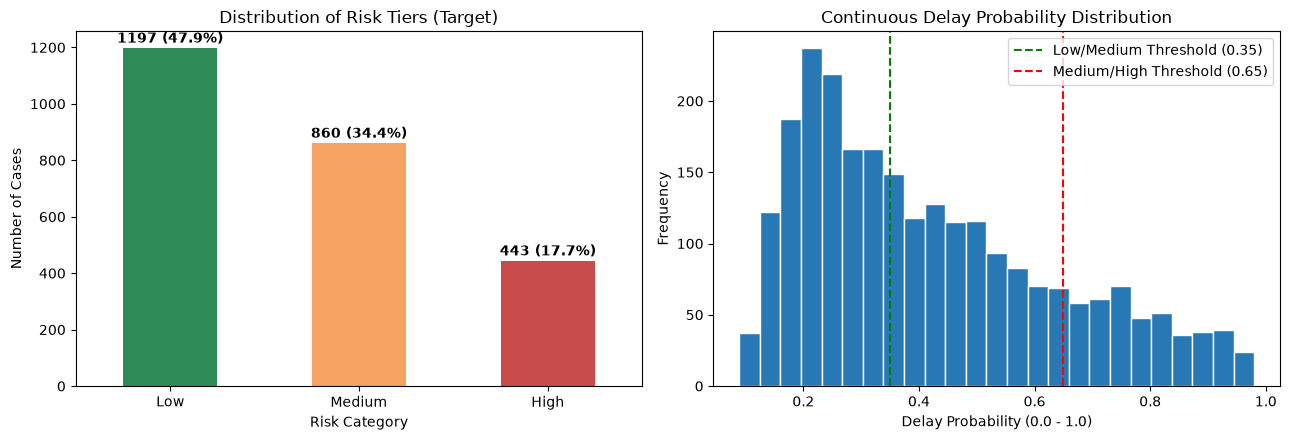

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Risk tiers
risk_counts = df['delay_risk'].value_counts()[['Low', 'Medium', 'High']]
colors = ['#2E8B57', '#F4A460', '#C94C4C']
risk_counts.plot(kind='bar', ax=axes[0], color=colors, rot=0)
axes[0].set_title('Distribution of Risk Tiers (Target)')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Number of Cases')
for i, v in enumerate(risk_counts):
    axes[0].text(i, v + 20, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Delay probability histogram
axes[1].hist(df['delay_probability'], bins=25, color='#2878B5', edgecolor='white')
axes[1].set_title('Continuous Delay Probability Distribution')
axes[1].set_xlabel('Delay Probability (0.0 - 1.0)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0.35, color='green', linestyle='--', label='Low/Medium Threshold (0.35)')
axes[1].axvline(0.65, color='red', linestyle='--', label='Medium/High Threshold (0.65)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Domain Feature Engineering

To capture land acquisition bottlenecks, we create composite domain features:
- `dispute_score`: Sum of court cases, title disputes, and public objections.
- `severe_legal_risk`: Interaction between pending litigation AND ownership disputes.
- `possession_lag`: Lag between financial awards passed and physical possession.
- `area_per_owner`: Parcel fragmentation measure.
- `unfunded_amount`: Financial liability when compensation funds are not available.

In [3]:
def engineer_features(data_df: pd.DataFrame) -> pd.DataFrame:
    res = data_df.copy()
    res['area_per_owner'] = res['land_area_hectares'] / (res['affected_owner_count'] + 1)
    res['cost_per_hectare'] = res['compensation_estimate_inr_lakh'] / (res['land_area_hectares'] + 0.01)
    res['dispute_score'] = res['has_title_dispute'] + res['has_court_case'] + res['has_objection']
    res['severe_legal_risk'] = ((res['has_court_case'] == 1) & (res['has_title_dispute'] == 1)).astype(int)
    res['milestone_avg'] = (
        res['land_notified_percent'] + res['award_completed_percent'] +
        res['compensation_disbursed_percent'] + res['possession_completed_percent']
    ) / 4.0
    res['possession_lag'] = res['award_completed_percent'] - res['possession_completed_percent']
    res['disbursal_ratio'] = res['compensation_disbursed_percent'] / (res['award_completed_percent'] + 1e-3)
    res['unfunded_amount'] = (1 - res['compensation_funding_available']) * res['compensation_estimate_inr_lakh']
    return res

df_feat = engineer_features(df)
sample_cols = ['area_per_owner', 'dispute_score', 'severe_legal_risk', 'milestone_avg', 'possession_lag', 'unfunded_amount']
df_feat[sample_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
area_per_owner,2500.0,0.56,0.87,0.01,0.15,0.31,0.64,19.11
dispute_score,2500.0,0.40,0.64,0.00,0.00,0.00,1.00,3.00
severe_legal_risk,2500.0,0.03,0.18,0.00,0.00,0.00,0.00,1.00
milestone_avg,2500.0,44.26,31.64,0.00,13.47,43.34,75.05,99.62
possession_lag,2500.0,23.65,15.13,0.00,11.98,24.10,34.70,71.70
unfunded_amount,2500.0,34.00,158.43,0.00,0.00,0.00,0.00,4435.35


## 4. Evaluation of Trained Model Artifact

In [4]:
with open(METRICS_PATH, 'r', encoding='utf-8') as f:
    metrics = json.load(f)

print('=== MODEL PERFORMANCE METRICS ===')
print(f"Architecture:                      {metrics.get('model_architecture', 'Dual XGBoost')}")
print(f"Risk Level Classification Accuracy: {metrics['risk_classification_accuracy'] * 100:.2f}%")
print(f"Probability Regression R² Score:   {metrics['probability_r2_score']:.4f}")
print(f"Probability Mean Absolute Error:   {metrics['probability_mae'] * 100:.2f}%")
print(f"Binary Delay Detection Accuracy:   {metrics['binary_accuracy'] * 100:.2f}%")
print(f"Binary Delay Detection Recall:     {metrics['binary_delayed_recall'] * 100:.2f}%")

=== MODEL PERFORMANCE METRICS ===
Architecture:                      XGBoost Dual-Engine (Classifier + Calibrated Regressor) with Feature Engineering
Risk Level Classification Accuracy: 93.00%
Probability Regression R² Score:   0.9815
Probability Mean Absolute Error:   2.17%
Binary Delay Detection Accuracy:   68.60%
Binary Delay Detection Recall:     55.98%


## 5. Held-out Test Set Evaluation & Confusion Matrix

Classification Report for Risk Categories:
              precision    recall  f1-score   support

         Low      0.966     0.941     0.953       239
      Medium      0.866     0.942     0.903       172
        High      0.975     0.876     0.923        89

    accuracy                          0.930       500
   macro avg      0.936     0.920     0.926       500
weighted avg      0.933     0.930     0.930       500



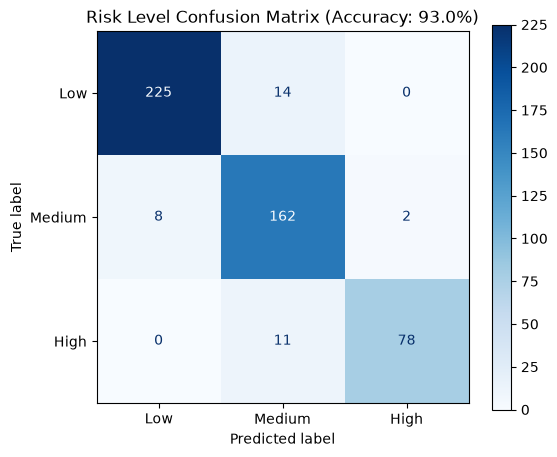

In [5]:
bundle = joblib.load(MODEL_PATH)
preprocessor = bundle['preprocessor']
risk_clf = bundle['risk_classifier']
prob_reg = bundle['prob_regressor']
cat_features = bundle['categorical_features']
eng_numeric = bundle['engineered_numeric']

all_features = cat_features + eng_numeric
X = df_feat[all_features]
inv_risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_risk = df['delay_risk'].map(inv_risk_map)
y_prob = df['delay_probability']

_, x_test, _, y_test_risk, _, y_test_prob = train_test_split(
    X, y_risk, y_prob, test_size=0.20, random_state=20260906, stratify=y_risk
)

x_test_trans = preprocessor.transform(x_test)
y_pred_risk = risk_clf.predict(x_test_trans)
y_pred_prob = prob_reg.predict(x_test_trans)

print('Classification Report for Risk Categories:')
print(classification_report(y_test_risk, y_pred_risk, target_names=['Low', 'Medium', 'High'], digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_risk, y_pred_risk, 
    display_labels=['Low', 'Medium', 'High'], 
    cmap='Blues', 
    ax=ax,
    values_format='d'
)
ax.set_title(f'Risk Level Confusion Matrix (Accuracy: {accuracy_score(y_test_risk, y_pred_risk)*100:.1f}%)')
plt.show()

## 6. Delay Probability Calibration & Error Scatter

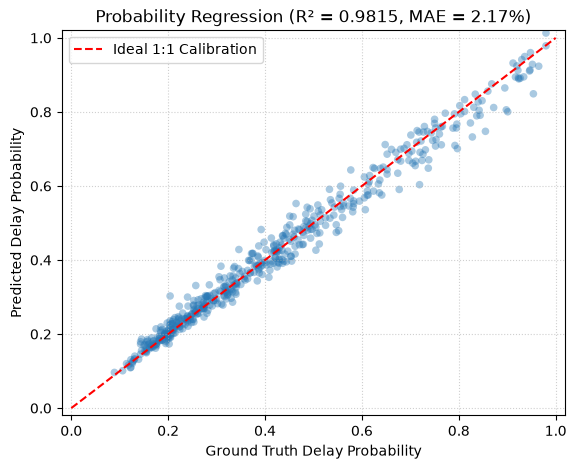

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(y_test_prob, y_pred_prob, alpha=0.4, color='#2878B5', edgecolors='none', s=30)
ax.plot([0, 1], [0, 1], 'r--', label='Ideal 1:1 Calibration')
ax.set_title(f'Probability Regression (R² = {r2_score(y_test_prob, y_pred_prob):.4f}, MAE = {mean_absolute_error(y_test_prob, y_pred_prob)*100:.2f}%)')
ax.set_xlabel('Ground Truth Delay Probability')
ax.set_ylabel('Predicted Delay Probability')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 7. Feature Importances (XGBoost)

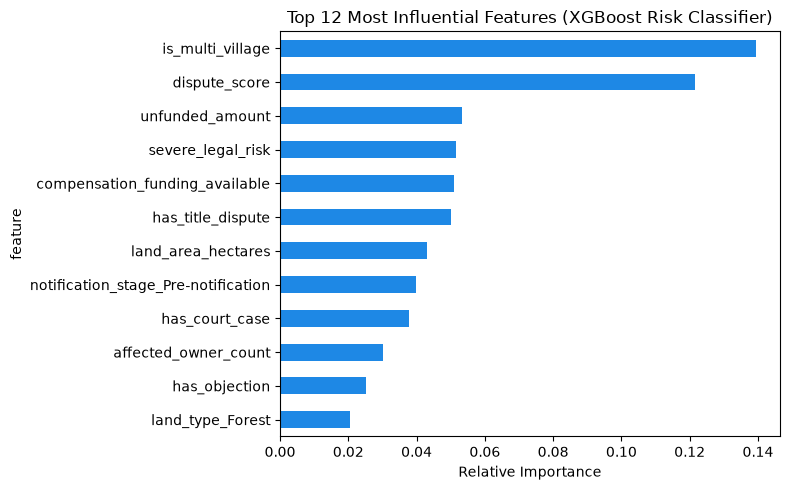

In [7]:
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1] for name in feature_names]

importance_df = pd.DataFrame({
    'feature': clean_names,
    'importance': risk_clf.feature_importances_
}).sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
importance_df.sort_values('importance').plot.barh(
    x='feature', y='importance', legend=False, ax=ax, color='#1E88E5'
)
ax.set_title('Top 12 Most Influential Features (XGBoost Risk Classifier)')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.show()

## 8. Real-world Flowchart Test Case Simulation

In [8]:
# Sample Case from Architecture Flowchart
flowchart_sample = {
    'state': 'Uttar Pradesh',
    'district_type': 'Rural',
    'project_type': 'Railway',
    'land_type': 'Agricultural',
    'notification_stage': '3A issued',
    'land_area_hectares': 8.2 * 0.404686,  # 8.2 acres to hectares
    'affected_owner_count': 12,
    'is_multi_village': 1,
    'has_title_dispute': 1,
    'has_court_case': 1,
    'has_objection': 1,
    'compensation_estimate_inr_lakh': 350.0,
    'compensation_funding_available': 0,
    'days_since_case_opened': 240,
    'land_notified_percent': 60.0,
    'award_completed_percent': 30.0,
    'compensation_disbursed_percent': 15.0,
    'possession_completed_percent': 0.0
}

sample_df = pd.DataFrame([flowchart_sample])
sample_feat = engineer_features(sample_df)
sample_trans = preprocessor.transform(sample_feat[all_features])

pred_prob = float(np.clip(prob_reg.predict(sample_trans)[0], 0.0, 1.0))
risk_probs = risk_clf.predict_proba(sample_trans)[0]
risk_level = 'High' if pred_prob >= 0.65 else ('Medium' if pred_prob >= 0.35 else 'Low')

print('=== SIMULATION OUTPUT ===')
print(f"Delay Probability:       {pred_prob * 100:.1f}%")
print(f"Assigned Risk Tier:      {risk_level}")
print(f"Risk Distribution:       Low: {risk_probs[0]*100:.1f}%, Medium: {risk_probs[1]*100:.1f}%, High: {risk_probs[2]*100:.1f}%")
print(f"Operational Outcome:     Delayed Project Alert Fired!")

=== SIMULATION OUTPUT ===
Delay Probability:       91.1%
Assigned Risk Tier:      High
Risk Distribution:       Low: 0.2%, Medium: 1.1%, High: 98.8%
Operational Outcome:     Delayed Project Alert Fired!
